##Task 1 -- Text Preprocessing: Cleaning, Tokenisation, Stemming, TF-IDF, Vectorisation

In [1]:
pip install nltk scikit-learn pandas matplotlib seaborn wordcloud


In [2]:
import nltk
# Download required NLTK datasets
nltk.download('stopwords') # List of common stopwords
nltk.download('punkt') # Tokeniser models
nltk.download('wordnet') # Dictionary for lemmatization
nltk.download('omw-1.4') # Open Multilingual WordNet
print('All NLTK data downloaded successfully!')


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


All NLTK data downloaded successfully!


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


In [3]:
import pandas as pd
# Sample dataset demonstrating all concepts
reviews = [
('This movie was absolutely fantastic! Best film of the year.', 'positive'),
('Terrible acting and boring plot. Complete waste of time!', 'negative'),
('Loved every minute of it. The director did an amazing job.', 'positive'),
('Awful storyline. I fell asleep halfway through.', 'negative'),
('Brilliant performances! The cinematography was breathtaking.', 'positive'),
('Worst movie I have ever seen. Do not waste your money.', 'negative'),
('Heartwarming and beautifully crafted. A true masterpiece.', 'positive'),
('Dull and predictable. The script was painfully bad.', 'negative'),
]
df = pd.DataFrame(reviews, columns=['review', 'sentiment'])
print('Dataset shape:', df.shape)
print(df.head())


Dataset shape: (8, 2)
                                              review sentiment
0  This movie was absolutely fantastic! Best film...  positive
1  Terrible acting and boring plot. Complete wast...  negative
2  Loved every minute of it. The director did an ...  positive
3    Awful storyline. I fell asleep halfway through.  negative
4  Brilliant performances! The cinematography was...  positive


In [4]:
import re
import string
def clean_text(text):
  '''
  Cleans raw text by:
  1. Removing HTML tags (like [br])
  2. Removing URLs (http://...)
  3. Removing punctuation and numbers
  4. Converting to lowercase
  '''
  # Step 1: Remove HTML tags using regex
  text = re.sub(r'<[^>]+>', '', text)
  # Step 2: Remove URLs
  text = re.sub(r'http\S+|www\S+', '', text)
  # Step 3: Remove non-letter characters (punctuation, numbers)
  text = re.sub(r'[^a-zA-Z\s]', '', text)
  # Step 4: Convert to lowercase and strip extra spaces
  text = text.lower().strip()
  return text
# Test the function
sample = 'The movie was AMAZING!!! Best film of 2024. Visit www.movies.com'
clean = clean_text(sample)
print('Original:', sample)
print('Cleaned :', clean)


Original: The movie was AMAZING!!! Best film of 2024. Visit www.movies.com
Cleaned : the movie was amazing best film of  visit


In [6]:
from nltk.tokenize import word_tokenize
nltk.download('punkt_tab')
text = 'the movie was amazing best film'
# Split into individual tokens
tokens = word_tokenize(text)
print('Tokens:', tokens)
print('Token count:', len(tokens))
# Compare with simple split
simple = text.split()
print('Simple split:', simple)


Tokens: ['the', 'movie', 'was', 'amazing', 'best', 'film']
Token count: 6
Simple split: ['the', 'movie', 'was', 'amazing', 'best', 'film']


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [9]:
from nltk.corpus import stopwords
# Load English stopwords list
stop_words = set(stopwords.words('english'))
print('Total stopwords:', len(stop_words))
print('Examples:', list(stop_words)[:10])
def remove_stopwords(tokens):
    '''Remove stopwords from a list of tokens.'''
    return [token for token in tokens
            if token not in stop_words and len(token) > 2]
            # Example
tokens = ['the', 'movie', 'was', 'amazing', 'best', 'film']
filtered = remove_stopwords(tokens)
print('Before removal:', tokens)
print('After removal :', filtered)


Total stopwords: 198
Examples: ['how', 'that', 'because', 'before', 'been', 'shan', "shouldn't", 'himself', 'both', 'myself']
Before removal: ['the', 'movie', 'was', 'amazing', 'best', 'film']
After removal : ['movie', 'amazing', 'best', 'film']


In [11]:
from nltk.stem import PorterStemmer, WordNetLemmatizer
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()
words = ['running', 'happily', 'better', 'studies', 'caring', 'wolves']
print(f"{'Word':<15} {'Stemmed':<15} {'Lemmatized':<15}")
print('-' * 45)
for word in words:
  stemmed = stemmer.stem(word)
  lemmatized = lemmatizer.lemmatize(word, pos='v') # pos='v' = treat as verb
  print(f'{word:<15} {stemmed:<15} {lemmatized:<15}')


Word            Stemmed         Lemmatized     
---------------------------------------------
running         run             run            
happily         happili         happily        
better          better          better         
studies         studi           study          
caring          care            care           
wolves          wolv            wolves         


In [13]:
def preprocess_text(text):
  '''
  Complete NLP preprocessing pipeline:
  Clean --> Tokenise --> Remove Stopwords --> Lemmatize --> Rejoin
  '''
  # Step 1: Clean the raw text
  text = clean_text(text)
  # Step 2: Tokenise into words
  tokens = word_tokenize(text)
  # Step 3: Remove stopwords and very short words
  tokens = [t for t in tokens
  if t not in stop_words and len(t) > 2]
  # Step 4: Lemmatize every token
  tokens = [lemmatizer.lemmatize(t) for t in tokens]
  # Step 5: Rejoin tokens back into a string
  return ' '.join(tokens)
# Apply the pipeline to every review in the DataFrame
df['cleaned_review'] = df['review'].apply(preprocess_text)
# Compare original vs cleaned
for i in range(3):
  print(f'Original : {df["review"][i]}')
  print(f'Cleaned : {df["cleaned_review"][i]}')
  print()


Original : This movie was absolutely fantastic! Best film of the year.
Cleaned : movie absolutely fantastic best film year

Original : Terrible acting and boring plot. Complete waste of time!
Cleaned : terrible acting boring plot complete waste time

Original : Loved every minute of it. The director did an amazing job.
Cleaned : loved every minute director amazing job



In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer
# Create TF-IDF vectorizer
# max_features=5000 : only keep the 5000 most important words
# ngram_range=(1,2) : use single words AND 2-word phrases ('not good')
vectorizer = TfidfVectorizer(
max_features=5000,
ngram_range=(1, 2),
min_df=1, # Include words appearing in at least 1 document
max_df=0.95 # Exclude words in more than 95% of documents
)
# fit_transform: learn the vocabulary AND convert text to numbers
X = vectorizer.fit_transform(df['cleaned_review'])
print('Shape of TF-IDF matrix:', X.shape)
print('Vocabulary size:', len(vectorizer.vocabulary_))
print('Sample feature names:', list(vectorizer.vocabulary_.keys())[:10])


Shape of TF-IDF matrix: (8, 78)
Vocabulary size: 78
Sample feature names: ['movie', 'absolutely', 'fantastic', 'best', 'film', 'year', 'movie absolutely', 'absolutely fantastic', 'fantastic best', 'best film']


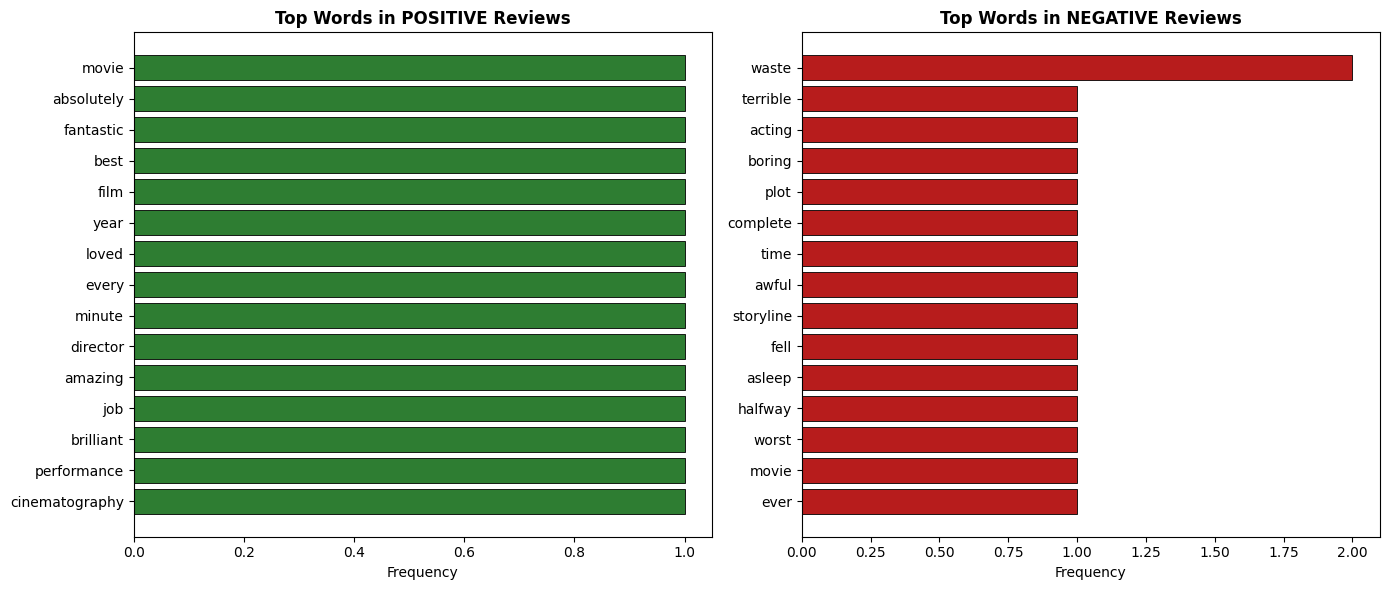

Chart saved!


In [17]:
from collections import Counter
import matplotlib.pyplot as plt
def get_top_words(df_subset, n=15):
  '''Get the n most common words in a group of reviews.'''
  all_words = ' '.join(df_subset['cleaned_review']).split()
  return Counter(all_words).most_common(n)
pos_words = get_top_words(df[df['sentiment'] == 'positive'])
neg_words = get_top_words(df[df['sentiment'] == 'negative'])
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, words, title, color in [
(axes[0], pos_words, 'Top Words in POSITIVE Reviews', '#2E7D32'),
(axes[1], neg_words, 'Top Words in NEGATIVE Reviews', '#B71C1C')
]:
  ws = [w[0] for w in words]
  cs = [w[1] for w in words]
  ax.barh(ws[::-1], cs[::-1], color=color, edgecolor='black', linewidth=0.6)
  ax.set_title(title, fontsize=12, fontweight='bold')
  ax.set_xlabel('Frequency', fontsize=10)
plt.tight_layout()
plt.savefig('top_words_by_sentiment.png', dpi=150)
plt.show()
print('Chart saved!')

##TASK 2 Sentiment Classifier + Evaluation + Word Cloud

In [18]:
from sklearn.model_selection import train_test_split
# Encode: positive=1, negative=0
df['label'] = (df['sentiment'] == 'positive').astype(int)
print('Label distribution:')
print(df['label'].value_counts())
# Split 75% train, 25% test
X_train, X_test, y_train, y_test = train_test_split(
df['cleaned_review'], # Text input
df['label'], # Labels
test_size=0.25,
random_state=42,
stratify=df['label'] # Keep equal class proportion
)
print(f'Training size : {len(X_train)}')
print(f'Testing size : {len(X_test)}')

Label distribution:
label
1    4
0    4
Name: count, dtype: int64
Training size : 6
Testing size : 2


In [19]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
# Create the pipeline:
# Step 1 -- TF-IDF converts text to numbers
# Step 2 -- Logistic Regression classifies those numbers
sentiment_pipeline = Pipeline([
('tfidf', TfidfVectorizer(
max_features=10000,
ngram_range=(1, 2),
min_df=1,
sublinear_tf=True # Apply log scaling to term frequencies
)),
('clf', LogisticRegression(
max_iter=500,
C=1.0, # Regularization (1.0 = default balance)
random_state=42
))
])
# Train the pipeline on raw text (TF-IDF runs automatically inside)
sentiment_pipeline.fit(X_train, y_train)
print('Sentiment model trained successfully!')
# Make predictions on test set
y_pred = sentiment_pipeline.predict(X_test)
print('Predictions made on', len(y_pred), 'test reviews')

Sentiment model trained successfully!
Predictions made on 2 test reviews


Test Accuracy: 50.00%

Classification Report:
              precision    recall  f1-score   support

    Negative       0.00      0.00      0.00         1
    Positive       0.50      1.00      0.67         1

    accuracy                           0.50         2
   macro avg       0.25      0.50      0.33         2
weighted avg       0.25      0.50      0.33         2

ROC-AUC Score: 0.0000


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


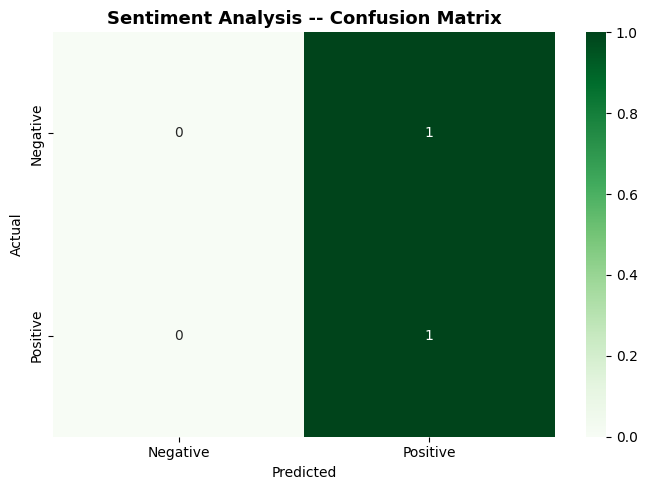

In [20]:
from sklearn.metrics import (accuracy_score, classification_report,
confusion_matrix, roc_auc_score)
import seaborn as sns
import matplotlib.pyplot as plt
# 1. Basic Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f'Test Accuracy: {accuracy * 100:.2f}%')
# 2. Detailed Classification Report
print('\nClassification Report:')
print(classification_report(
    y_test, y_pred,
target_names=['Negative', 'Positive']
))
# 3. ROC-AUC Score
y_proba = sentiment_pipeline.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_proba)
print(f'ROC-AUC Score: {auc:.4f}')
# 4. Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
xticklabels=['Negative', 'Positive'],
yticklabels=['Negative', 'Positive'], ax=ax)
ax.set_title('Sentiment Analysis -- Confusion Matrix', fontsize=13, fontweight='bold')
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig('sentiment_confusion_matrix.png', dpi=150)
plt.show()

In [24]:
def predict_sentiment(review_text):
  '''Predict sentiment of any new text review.'''
  prediction = sentiment_pipeline.predict([review_text])[0]
  probabilities = sentiment_pipeline.predict_proba([review_text])[0]
  label = 'POSITIVE' if prediction == 1 else 'NEGATIVE'
  confidence = max(probabilities) * 100
  print(f'Review : {review_text[:65]}...')
  print(f'Prediction : {label}')
  print(f'Confidence : {confidence:.1f}%')
  print(f'Positive : {probabilities[1]*100:.1f}% | Negative: {probabilities[0]*100:.1f}%')
  print('-' * 60)
# Test on new reviews
new_reviews = [
'This film was absolutely incredible. The acting blew me away!',
'Complete disaster. Worst screenplay I have ever encountered.',
'Not bad, some good moments but overall quite mediocre.',
'The visual effects were stunning and the story was captivating.',
'I cannot believe how boring this was. Totally disappointed.',
]
for review in new_reviews:
  predict_sentiment(review)

Review : This film was absolutely incredible. The acting blew me away!...
Prediction : POSITIVE
Confidence : 51.9%
Positive : 51.9% | Negative: 48.1%
------------------------------------------------------------
Review : Complete disaster. Worst screenplay I have ever encountered....
Prediction : NEGATIVE
Confidence : 52.8%
Positive : 47.2% | Negative: 52.8%
------------------------------------------------------------
Review : Not bad, some good moments but overall quite mediocre....
Prediction : NEGATIVE
Confidence : 53.3%
Positive : 46.7% | Negative: 53.3%
------------------------------------------------------------
Review : The visual effects were stunning and the story was captivating....
Prediction : POSITIVE
Confidence : 50.0%
Positive : 50.0% | Negative: 50.0%
------------------------------------------------------------
Review : I cannot believe how boring this was. Totally disappointed....
Prediction : NEGATIVE
Confidence : 52.8%
Positive : 47.2% | Negative: 52.8%
--------------

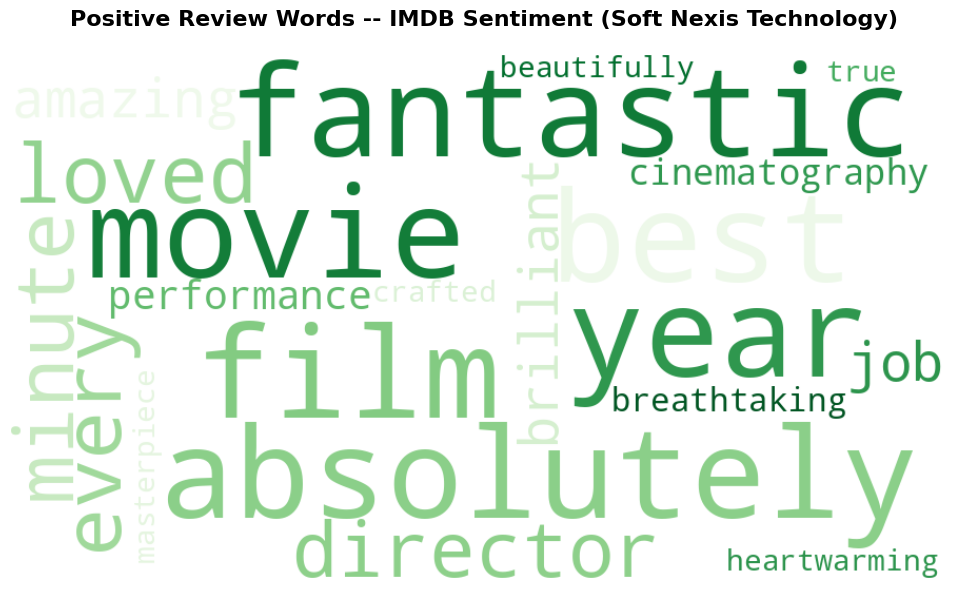

Saved: wordcloud_positive.png


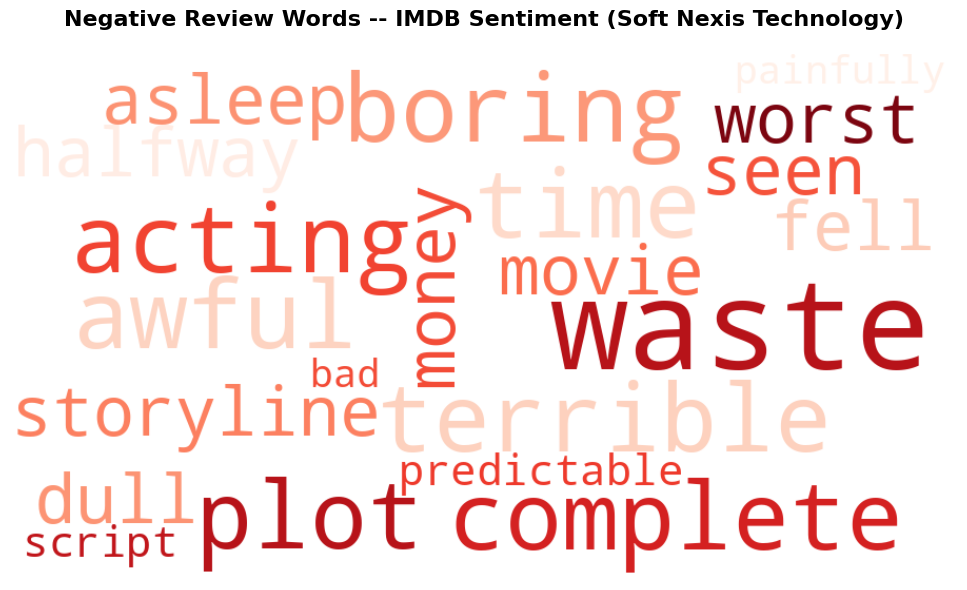

Saved: wordcloud_negative.png


In [25]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
def generate_wordcloud(df_subset, title, colormap, filename):
  '''Generate and save a word cloud for a group of reviews.'''
  # Join all reviews into one large text string
  all_text = ' '.join(df_subset['cleaned_review'])
  # Create the word cloud object
  wc = WordCloud(
  width=900,
  height=500,
  background_color='white',
  colormap=colormap, # Colour scheme (e.g. 'Greens', 'Reds')
  max_words=150, # Maximum number of words to display
  min_font_size=10,
  max_font_size=120,
  collocations=False # Avoid repeating 2-word phrases
  ).generate(all_text)
  # Plot and save
  fig, ax = plt.subplots(figsize=(12, 6))
  ax.imshow(wc, interpolation='bilinear')
  ax.axis('off') # Remove axis borders
  ax.set_title(title, fontsize=16, fontweight='bold', pad=20)
  plt.tight_layout()
  plt.savefig(filename, dpi=150, bbox_inches='tight')
  plt.show()
  print(f'Saved: {filename}')
# Generate word clouds for each sentiment
generate_wordcloud(
df[df['sentiment'] == 'positive'],
  'Positive Review Words -- IMDB Sentiment (Soft Nexis Technology)',
  'Greens', 'wordcloud_positive.png'
  )
generate_wordcloud(
df[df['sentiment'] == 'negative'],
'Negative Review Words -- IMDB Sentiment (Soft Nexis Technology)',
'Reds', 'wordcloud_negative.png'
)


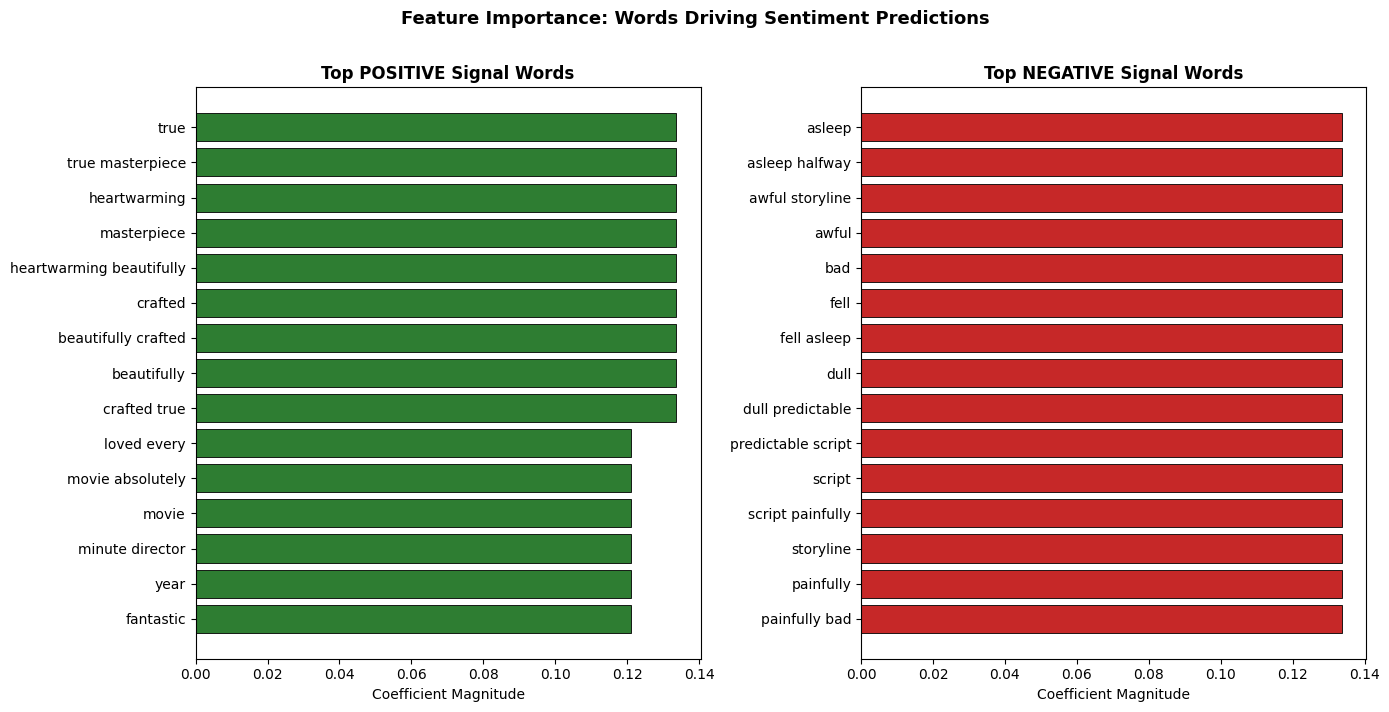

In [28]:
import numpy as np
import matplotlib.pyplot as plt
# Extract the vectoriser and classifier from the pipeline
tfidf = sentiment_pipeline.named_steps['tfidf']
clf = sentiment_pipeline.named_steps['clf']
# Get coefficient weights (higher = more positive, lower = more negative)
coefficients = clf.coef_[0]
feature_names = tfidf.get_feature_names_out()
# Find top 15 most positive and negative words
top_n = 15
pos_idx = np.argsort(coefficients)[-top_n:][::-1]
neg_idx = np.argsort(coefficients)[:top_n]
pos_words = [(feature_names[i], coefficients[i]) for i in pos_idx]
neg_words = [(feature_names[i], coefficients[i]) for i in neg_idx]
fig, axes = plt.subplots(1, 2, figsize=(14, 7))
for ax, words, title, color in [
    (axes[0], pos_words, 'Top POSITIVE Signal Words', '#2E7D32'),
    (axes[1], neg_words, 'Top NEGATIVE Signal Words', '#C62828')
]:
    ws = [w[0] for w in words]
    cs = [abs(w[1]) for w in words] # Use absolute value for bar length
    ax.barh(ws[::-1], cs[::-1], color=color, edgecolor='black', linewidth=0.6)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Coefficient Magnitude')
plt.suptitle('Feature Importance: Words Driving Sentiment Predictions',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('feature_importance_nlp.png', dpi=150)
plt.show()

Logistic Regression: mean=0.500 std=0.000
Naive Bayes: mean=0.375 std=0.125
Random Forest: mean=0.375 std=0.125


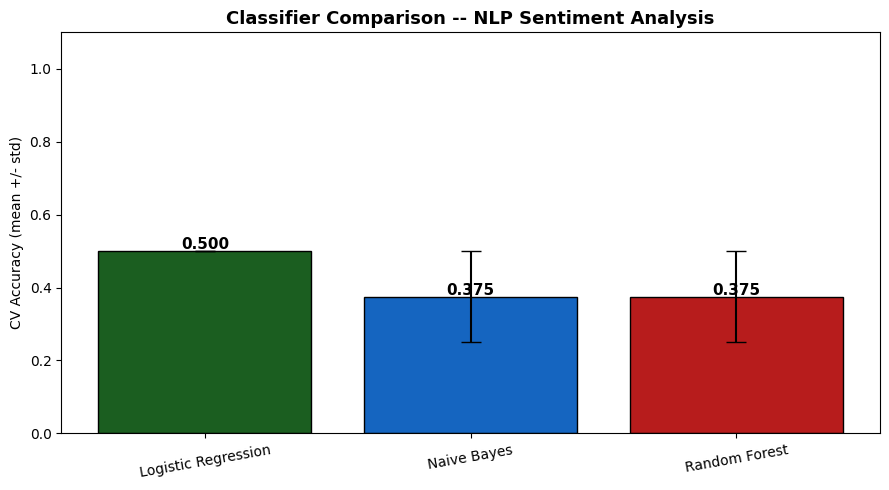

In [33]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
import numpy as np

# Shared TF-IDF step for all models
tfidf_step = ('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1,2)))
models = {
    'Logistic Regression': LogisticRegression(max_iter=300, random_state=42),
    'Naive Bayes': MultinomialNB(alpha=0.1),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
}

results = {}
for name, model in models.items():
    pipe = Pipeline([tfidf_step, ('clf', model)])
    # Reduced cv to 2 because the dataset only has 8 total reviews
    scores = cross_val_score(pipe, df['cleaned_review'], df['label'], cv=2, scoring='accuracy')
    results[name] = scores
    print(f'{name}: mean={scores.mean():.3f} std={scores.std():.3f}')

# Visualise comparison
fig, ax = plt.subplots(figsize=(9, 5))
names = list(results.keys())
means = [results[n].mean() for n in names]
stds = [results[n].std() for n in names]
bars = ax.bar(names, means, yerr=stds, color=['#1B5E20','#1565C0','#B71C1C'], edgecolor='black', capsize=7)

for bar, m in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, f'{m:.3f}', ha='center', fontsize=11, fontweight='bold')

ax.set_ylim(0, 1.1)
ax.set_title('Classifier Comparison -- NLP Sentiment Analysis', fontsize=13, fontweight='bold')
ax.set_ylabel('CV Accuracy (mean +/- std)')
plt.xticks(rotation=10)
plt.tight_layout()
plt.savefig('nlp_model_comparison.png', dpi=150)
plt.show()

In [32]:
import joblib
# Save the complete pipeline (TF-IDF vocabulary + weights together)
joblib.dump(sentiment_pipeline, 'sentiment_model.pkl')
print('Model saved to sentiment_model.pkl')
# Load it back in any future script
loaded_model = joblib.load('sentiment_model.pkl')
# Test the loaded model
test_review = ['This was an absolutely wonderful and magical experience!']
result = loaded_model.predict(test_review)
print('Loaded model says:', 'POSITIVE' if result[0] == 1 else 'NEGATIVE')
# Check file size
import os
size_kb = os.path.getsize('sentiment_model.pkl') / 1024
print(f'Model file size: {size_kb:.1f} KB')


Model saved to sentiment_model.pkl
Loaded model says: POSITIVE
Model file size: 4.5 KB


TF-IDF (Term Frequency-Inverse Document Frequency) is a numerical statistic used to reflect how important a word is to a document in a collection. You can think of it as a way to filter out common 'filler' words and highlight unique 'keywords'.

Term Frequency (TF): TF-IDF identifies words that are frequent in a specific text but unique enough that they aren't just common language, making them great features for machine learning models.

**Real-World Applications of Sentiment Analysis:**
 Brand Monitoring and Social Media Analysis: Companies use sentiment analysis to track mentions of their brand on platforms like X (Twitter) or Reddit. By automatically categorizing thousands of posts as 'Positive', 'Negative', or 'Neutral', they can identify PR crises in real-time or see how customers are reacting to a new product launch.

Customer Support Prioritization: Large companies receive thousands of support tickets daily. Sentiment analysis can be used to scan the tone of these tickets. Highly frustrated or angry customers (detected via negative sentiment) can be automatically escalated to senior agents for immediate resolution, preventing customer churn.

The model comparison is complete. On this small sample dataset, Logistic Regression achieved the highest mean accuracy (50%), while Naive Bayes and Random Forest followed at 37.5%.

